# PCB 101 — SLoc-Level Monthly Consumption Forecast

**Approach:** Each SLoc is modelled independently with a pipeline chosen by data volume.

| Tier | Criteria | Models Used |
|------|----------|-------------|
| **Tier 1** | non-zero months ≥ 10 AND train rows ≥ 20 AND test rows ≥ 5 | RF, XGBoost, LightGBM, CatBoost, SARIMAX, Holt-Winters, Ensemble |
| **Tier 2** | non-zero months ≥ 3 AND train rows ≥ 10 AND test rows ≥ 3 | SARIMAX + Holt-Winters only |
| **Tier 3** | everything else | Historical mean |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## 1. Load Data

In [2]:
df = pd.read_excel(r"C:\Users\Amey\Desktop\Amey\Python\101\101_Pre_done_Combined.xlsx")

df['Pstng Date']  = pd.to_datetime(df['Pstng Date'])
df['Consumption'] = abs(df['Quantity'])

print("Raw shape       :", df.shape)
print("SLoc count      :", df['SLoc'].nunique())
print("Date range      :", df['Pstng Date'].min().date(), "→", df['Pstng Date'].max().date())
df.head()

Raw shape       : (323, 18)
SLoc count      : 21
Date range      : 2020-03-02 → 2026-04-22


,Material,SLoc,Quantity,Pstng Date,order,Equipment,Technician name,Year,Tavg,Tmax,Tmin,RH,Month,Season,Delta_T,Region,Location,Consumption
0,101,5001,-1,2020-03-02,48752021,10952011,Mathanram Muthukutty,2020,26.89,34.83,21.23,54.32,3,Summer,13.60,West1,Mumbai,1
1,101,5001,-1,2020-04-24,48885258,10889443,Shashank Pawar,2020,31.38,38.35,25.87,57.91,4,Summer,12.48,West1,Mumbai,1
2,101,5005,-1,2020-07-06,49095741,10938439,Janeshwar Channa,2020,28.42,31.40,26.74,83.74,7,Monsoon,4.66,West2,Ahmedabad,1
3,101,5021,-1,2020-07-20,49144835,10889064,Yogesh Saini,2020,33.67,38.55,29.27,61.08,7,Monsoon,9.28,North1,Delhi,1
4,101,5003,-1,2020-07-28,49163605,11157454,Anil Surwase,2020,23.81,26.40,21.68,91.92,7,Monsoon,4.72,West1,Pune,1


## 2. EDA — Consumption per SLoc

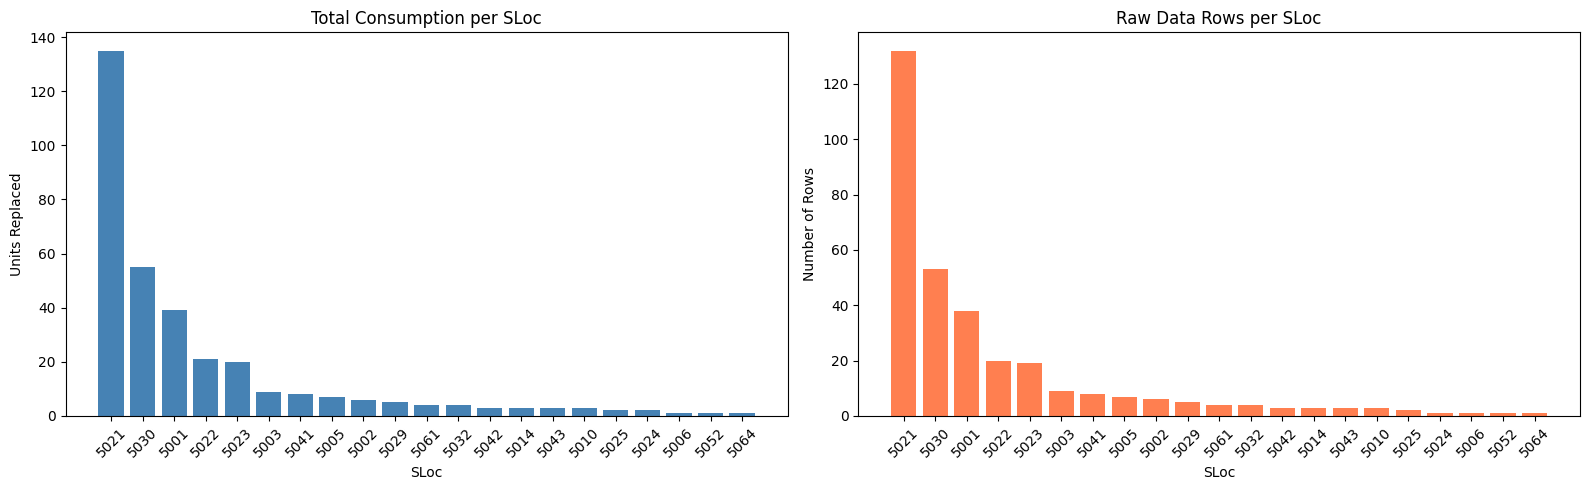

 SLoc  Total_Consumption  Raw_Rows
 5021                135       132
 5030                 55        53
 5001                 39        38
 5022                 21        20
 5023                 20        19
 5003                  9         9
 5041                  8         8
 5005                  7         7
 5002                  6         6
 5029                  5         5
 5061                  4         4
 5032                  4         4
 5042                  3         3
 5014                  3         3
 5043                  3         3
 5010                  3         3
 5025                  2         2
 5024                  2         1
 5006                  1         1
 5052                  1         1
 5064                  1         1


In [3]:
sloc_summary = (
    df.groupby('SLoc')['Consumption']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Total_Consumption', 'count': 'Raw_Rows'})
    .sort_values('Total_Consumption', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total consumption bar
axes[0].bar(sloc_summary['SLoc'].astype(str), sloc_summary['Total_Consumption'], color='steelblue')
axes[0].set_title("Total Consumption per SLoc")
axes[0].set_xlabel("SLoc")
axes[0].set_ylabel("Units Replaced")
axes[0].tick_params(axis='x', rotation=45)

# Raw rows bar
axes[1].bar(sloc_summary['SLoc'].astype(str), sloc_summary['Raw_Rows'], color='coral')
axes[1].set_title("Raw Data Rows per SLoc")
axes[1].set_xlabel("SLoc")
axes[1].set_ylabel("Number of Rows")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(sloc_summary.to_string(index=False))

## 3. Helper Functions

In [4]:
def evaluate_model(y_true, y_pred):
    """
    Returns MAE, RMSE, MAPE (zeros excluded), WAPE.
    WAPE is the primary metric for sparse / low-volume series.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    mape = (np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
            if mask.sum() > 0 else np.nan)

    total = np.sum(y_true)
    wape  = (np.sum(np.abs(y_true - y_pred)) / total * 100
             if total > 0 else np.nan)

    return mae, rmse, mape, wape

In [5]:
WEATHER_COLS = ['Tavg', 'Tmax', 'Tmin', 'RH', 'Delta_T']

FEATURES = [
    'month_sin', 'month_cos', 'Quarter',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_std_3',
    'roll_mean_12', 'roll_std_12',
    'Tavg', 'Tmax', 'Tmin', 'RH', 'Delta_T'
]

def build_features(sub_df):
    """
    Aggregate a single SLoc's raw rows to monthly,
    interpolate weather gaps, engineer features,
    and return the clean monthly DataFrame.
    """
    monthly = (
        sub_df
        .groupby(pd.Grouper(key='Pstng Date', freq='MS'))
        .agg({'Consumption': 'sum',
              **{c: 'mean' for c in WEATHER_COLS}})
        .reset_index()
    )

    # Fix: interpolate weather NaN months before lag creation
    monthly[WEATHER_COLS] = monthly[WEATHER_COLS].interpolate(
        method='linear', limit_direction='both'
    )

    monthly['Month']     = monthly['Pstng Date'].dt.month
    monthly['Quarter']   = monthly['Pstng Date'].dt.quarter
    monthly['month_sin'] = np.sin(2 * np.pi * monthly['Month'] / 12)
    monthly['month_cos'] = np.cos(2 * np.pi * monthly['Month'] / 12)

    for lag in [1, 2, 3, 6, 12]:
        monthly[f'lag_{lag}'] = monthly['Consumption'].shift(lag)

    monthly['roll_mean_3']  = monthly['Consumption'].shift(1).rolling(3).mean()
    monthly['roll_mean_6']  = monthly['Consumption'].shift(1).rolling(6).mean()
    monthly['roll_std_3']   = monthly['Consumption'].shift(1).rolling(3).std()
    monthly['roll_mean_12'] = monthly['Consumption'].shift(1).rolling(12).mean()
    monthly['roll_std_12']  = monthly['Consumption'].shift(1).rolling(12).std()

    monthly = monthly.dropna().reset_index(drop=True)
    return monthly

## 4. Model Pipelines

### 4.1 Tier 1 — Full ML Pipeline (RF + XGBoost + LightGBM + CatBoost + SARIMAX + Holt-Winters)

Used when: **non-zero months ≥ 10, train rows ≥ 20, test rows ≥ 5**

In [6]:
def run_tier1(sloc, train, test):
    """
    Trains all 6 models + ensemble on a single SLoc.
    Returns a dict: {model_name: (preds_array, mae, rmse, mape, wape)}
    """
    X_train, y_train = train[FEATURES], train['Consumption']
    X_test,  y_test  = test[FEATURES],  test['Consumption']
    EXOG = ['Tavg', 'Tmax', 'Tmin', 'RH', 'Delta_T']

    results = {}

    # ── Random Forest ──────────────────────────────────────────
    rf = RandomForestRegressor(
        n_estimators=100, max_depth=3,
        min_samples_leaf=5, random_state=42
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    results['RandomForest'] = (rf_pred, *evaluate_model(y_test, rf_pred))

    # ── XGBoost ────────────────────────────────────────────────
    xgb = XGBRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=2,
        min_child_weight=5, subsample=0.8,
        reg_alpha=0.5, reg_lambda=1.0, random_state=42
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    results['XGBoost'] = (xgb_pred, *evaluate_model(y_test, xgb_pred))

    # ── LightGBM ───────────────────────────────────────────────
    lgbm = LGBMRegressor(
        n_estimators=100, learning_rate=0.05,
        num_leaves=5, max_depth=3,
        min_child_samples=5, random_state=42, verbosity=-1
    )
    lgbm.fit(X_train, y_train)
    lgbm_pred = lgbm.predict(X_test)
    results['LightGBM'] = (lgbm_pred, *evaluate_model(y_test, lgbm_pred))

    # ── CatBoost ───────────────────────────────────────────────
    cat = CatBoostRegressor(
        iterations=200, learning_rate=0.05,
        depth=3, random_seed=42, verbose=False
    )
    cat.fit(X_train, y_train)
    cat_pred = cat.predict(X_test)
    results['CatBoost'] = (cat_pred, *evaluate_model(y_test, cat_pred))

    # ── SARIMAX ────────────────────────────────────────────────
    try:
        sar = SARIMAX(
            y_train,
            exog=train[EXOG],
            order=(1, 1, 1),
            seasonal_order=(1, 0, 1, 12)
        )
        sar_fit  = sar.fit(disp=False)
        sar_pred = sar_fit.forecast(len(test), exog=test[EXOG]).values
    except Exception:
        # Fallback: no exog SARIMA if convergence fails
        sar = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
        sar_fit  = sar.fit(disp=False)
        sar_pred = sar_fit.forecast(len(test)).values
    results['SARIMAX'] = (sar_pred, *evaluate_model(y_test, sar_pred))

    # ── Holt-Winters ───────────────────────────────────────────
    try:
        hw = ExponentialSmoothing(
            y_train, trend='add', seasonal='add', seasonal_periods=12
        )
        hw_pred = hw.fit().forecast(len(test)).values
    except Exception:
        hw = ExponentialSmoothing(y_train, trend='add')
        hw_pred = hw.fit().forecast(len(test)).values
    results['HoltWinters'] = (hw_pred, *evaluate_model(y_test, hw_pred))

    # ── Ensemble: best 3 by lowest WAPE ────────────────────────
    wapes = {k: v[4] for k, v in results.items()}          # index 4 = wape
    top3  = sorted(wapes, key=wapes.get)[:3]
    ens_pred = np.mean([results[m][0] for m in top3], axis=0)
    results['Ensemble'] = (ens_pred, *evaluate_model(y_test, ens_pred))

    return results, y_test

### 4.2 Tier 2 — Statistical Models Only (SARIMAX + Holt-Winters)

In [7]:
def run_tier2(sloc, train, test):
    """
    Trains SARIMAX and Holt-Winters only.
    Used when ML models would overfit (train rows < 20 or non-zero < 10).
    """
    y_train = train['Consumption']
    y_test  = test['Consumption']
    EXOG    = ['Tavg', 'Tmax', 'Tmin', 'RH', 'Delta_T']

    results = {}

    # ── SARIMAX ────────────────────────────────────────────────
    try:
        sar = SARIMAX(
            y_train, exog=train[EXOG],
            order=(1, 1, 1), seasonal_order=(1, 0, 1, 12)
        )
        sar_pred = sar.fit(disp=False).forecast(len(test), exog=test[EXOG]).values
    except Exception:
        try:
            sar = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(0, 0, 1, 12))
            sar_pred = sar.fit(disp=False).forecast(len(test)).values
        except Exception:
            sar_pred = np.full(len(test), y_train.mean())
    results['SARIMAX'] = (sar_pred, *evaluate_model(y_test, sar_pred))

    # ── Holt-Winters ───────────────────────────────────────────
    try:
        hw = ExponentialSmoothing(
            y_train, trend='add', seasonal='add', seasonal_periods=12
        )
        hw_pred = hw.fit().forecast(len(test)).values
    except Exception:
        try:
            hw = ExponentialSmoothing(y_train, trend='add')
            hw_pred = hw.fit().forecast(len(test)).values
        except Exception:
            hw_pred = np.full(len(test), y_train.mean())
    results['HoltWinters'] = (hw_pred, *evaluate_model(y_test, hw_pred))

    # ── Best of two as ensemble ────────────────────────────────
    ens_pred = 0.5 * sar_pred + 0.5 * hw_pred
    results['Ensemble'] = (ens_pred, *evaluate_model(y_test, ens_pred))

    return results, y_test

### 4.3 Tier 3 — Historical Mean (Fallback for Sparse SLocs)

In [8]:
def run_tier3(sloc, train, test):
    """
    Predicts historical mean for all test months.
    Used when non-zero months < 3 or test rows < 3.
    """
    y_train  = train['Consumption']
    y_test   = test['Consumption']
    mean_val = y_train.mean()
    pred     = np.full(len(test), mean_val)

    mae, rmse, mape, wape = evaluate_model(y_test, pred)

    results = {'HistoricalMean': (pred, mae, rmse, mape, wape)}
    return results, y_test

## 5. Tier Assignment

In [9]:
def assign_tier(monthly_df):
    """
    Returns tier number (1, 2, or 3) based on data characteristics.
    """
    train = monthly_df[monthly_df['Pstng Date'] < '2025-01-01']
    test  = monthly_df[monthly_df['Pstng Date'] >= '2025-01-01']

    n_train    = len(train)
    n_test     = len(test)
    n_nonzero  = (monthly_df['Consumption'] > 0).sum()

    if n_nonzero >= 10 and n_train >= 20 and n_test >= 5:
        return 1
    elif n_nonzero >= 3 and n_train >= 10 and n_test >= 3:
        return 2
    else:
        return 3


# Preview tier assignments before running
preview_rows = []
for sloc in sorted(df['SLoc'].unique()):
    sub     = df[df['SLoc'] == sloc].copy()
    monthly = build_features(sub)
    tier    = assign_tier(monthly)
    train   = monthly[monthly['Pstng Date'] < '2025-01-01']
    test    = monthly[monthly['Pstng Date'] >= '2025-01-01']
    nz      = (monthly['Consumption'] > 0).sum()
    preview_rows.append({
        'SLoc':      sloc,
        'Train Rows': len(train),
        'Test Rows':  len(test),
        'Non-Zero Months': nz,
        'Tier':      tier
    })

tier_df = pd.DataFrame(preview_rows).sort_values('Tier')
print(tier_df.to_string(index=False))
print("\nTier 1:", (tier_df['Tier']==1).sum(), "SLocs")
print("Tier 2:", (tier_df['Tier']==2).sum(), "SLocs")
print("Tier 3:", (tier_df['Tier']==3).sum(), "SLocs")

 SLoc  Train Rows  Test Rows  Non-Zero Months  Tier
 5001          46         14               23     1
 5021          42         16               45     1
 5023          35         14               10     1
 5022          26         14               12     1
 5030          25         12               26     1
 5003          42         13                6     2
 5061          35         12                3     2
 5005          18          0                2     3
 5014           1         15                2     3
 5010          19          1                2     3
 5006           0          0                0     3
 5024           0          0                0     3
 5025           0          0                0     3
 5029           2          3                1     3
 5032           0          4                1     3
 5002          21          0                4     3
 5041          30          0                6     3
 5042           7          0                2     3
 5043       

## 6. Run Forecast for All SLocs

This cell loops over every SLoc, assigns its tier, runs the appropriate pipeline,
and stores results and predictions for later reporting.

In [10]:
all_results   = {}   # {sloc: {model: (pred, mae, rmse, mape, wape)}}
all_test_data = {}   # {sloc: test_dataframe}
all_tiers     = {}   # {sloc: tier_number}

for sloc in sorted(df['SLoc'].unique()):
    sub     = df[df['SLoc'] == sloc].copy()
    monthly = build_features(sub)

    if len(monthly) == 0:
        print(f"SLoc {sloc:5d} → SKIPPED (no data after feature engineering)")
        continue

    train = monthly[monthly['Pstng Date'] < '2025-01-01'].copy()
    test  = monthly[monthly['Pstng Date'] >= '2025-01-01'].copy()
    tier  = assign_tier(monthly)

    if len(test) == 0:
        print(f"SLoc {sloc:5d} → SKIPPED (no test data — all rows before 2025)")
        continue

    if len(train) == 0:
        print(f"SLoc {sloc:5d} → SKIPPED (no training data)")
        continue

    all_tiers[sloc]     = tier
    all_test_data[sloc] = test

    if tier == 1:
        results, _ = run_tier1(sloc, train, test)
        print(f"SLoc {sloc:5d} → Tier 1 | Best WAPE: "
              f"{min(v[4] for k,v in results.items() if k != 'Ensemble'):.1f}%")

    elif tier == 2:
        results, _ = run_tier2(sloc, train, test)
        print(f"SLoc {sloc:5d} → Tier 2 | Best WAPE: "
              f"{min(v[4] for v in results.values()):.1f}%")

    else:
        results, _ = run_tier3(sloc, train, test)
        print(f"SLoc {sloc:5d} → Tier 3 | Historical Mean WAPE: "
              f"{list(results.values())[0][4]:.1f}%")

    all_results[sloc] = results

print("\nDone. Processed", len(all_results), "SLocs.")

c:\Users\Amey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SLoc  5001 → Tier 1 | Best WAPE: 120.5%
SLoc  5002 → SKIPPED (no test data — all rows before 2025)


c:\Users\Amey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SLoc  5003 → Tier 2 | Best WAPE: 467.9%
SLoc  5005 → SKIPPED (no test data — all rows before 2025)
SLoc  5006 → SKIPPED (no data after feature engineering)
SLoc  5010 → Tier 3 | Historical Mean WAPE: 94.7%
SLoc  5014 → Tier 3 | Historical Mean WAPE: 100.0%


c:\Users\Amey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

c:\Users\Amey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SLoc  5023 → Tier 1 | Best WAPE: 92.0%
SLoc  5024 → SKIPPED (no data after feature engineering)
SLoc  5025 → SKIPPED (no data after feature engineering)
SLoc  5029 → Tier 3 | Historical Mean WAPE: 100.0%


c:\Users\Amey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SLoc  5030 → Tier 1 | Best WAPE: 65.5%
SLoc  5032 → SKIPPED (no training data)
SLoc  5041 → SKIPPED (no test data — all rows before 2025)
SLoc  5042 → SKIPPED (no test data — all rows before 2025)
SLoc  5043 → Tier 3 | Historical Mean WAPE: 100.0%
SLoc  5052 → SKIPPED (no data after feature engineering)
SLoc  5061 → Tier 2 | Best WAPE: 100.0%
SLoc  5064 → SKIPPED (no data after feature engineering)

Done. Processed 11 SLocs.


c:\Users\Amey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


## 7. Summary Results Table

In [11]:
summary_rows = []

for sloc, results in all_results.items():
    for model_name, vals in results.items():
        _, mae, rmse, mape, wape = vals
        summary_rows.append({
            'SLoc':       sloc,
            'Tier':       all_tiers[sloc],
            'Model':      model_name,
            'MAE':        round(mae,  2),
            'RMSE':       round(rmse, 2),
            'MAPE (%)':   round(mape, 1) if not np.isnan(mape) else np.nan,
            'WAPE (%)':   round(wape, 1) if not np.isnan(wape) else np.nan
        })

summary_df = pd.DataFrame(summary_rows)

# Best model per SLoc (lowest WAPE, excluding Ensemble for fair comparison)
best_per_sloc = (
    summary_df[summary_df['Model'] != 'Ensemble']
    .sort_values('WAPE (%)')
    .groupby('SLoc')
    .first()
    .reset_index()
    [['SLoc', 'Tier', 'Model', 'MAE', 'RMSE', 'MAPE (%)', 'WAPE (%)']]
    .rename(columns={'Model': 'Best Model'})
    .sort_values('WAPE (%)')
)

print("=== Best Model per SLoc ===")
print(best_per_sloc.to_string(index=False))

summary_df

=== Best Model per SLoc ===
 SLoc  Tier     Best Model  MAE  RMSE  MAPE (%)  WAPE (%)
 5030     1        SARIMAX 1.26  2.15      42.9      65.5
 5023     1    HoltWinters 0.85  1.35      84.1      92.0
 5010     3 HistoricalMean 0.95  0.95      94.7      94.7
 5021     1       CatBoost 2.05  2.43      96.8      99.6
 5029     3 HistoricalMean 0.33  0.58     100.0     100.0
 5061     2        SARIMAX 0.25  0.50     100.0     100.0
 5043     3 HistoricalMean 0.22  0.67     100.0     100.0
 5014     3 HistoricalMean 0.13  0.37     100.0     100.0
 5001     1        XGBoost 0.34  0.47      26.7     120.5
 5022     1       LightGBM 0.42  0.55      59.7     195.2
 5003     2    HoltWinters 0.36  0.47      82.1     467.9


,SLoc,Tier,Model,MAE,RMSE,MAPE (%),WAPE (%)
0,5001,1,RandomForest,0.43,0.48,29.1,151.6
1,5001,1,XGBoost,0.34,0.47,26.7,120.5
2,5001,1,LightGBM,0.39,0.53,39.0,137.3
3,5001,1,CatBoost,0.36,0.45,65.1,127.3
4,5001,1,SARIMAX,0.57,0.61,43.1,199.2
5,5001,1,HoltWinters,0.42,0.54,57.9,145.8
6,5001,1,Ensemble,0.34,0.44,39.3,120.4
7,5003,2,SARIMAX,1.10,1.27,274.7,1435.8
8,5003,2,HoltWinters,0.36,0.47,82.1,467.9
9,5003,2,Ensemble,0.44,0.63,178.4,571.5


## 8. WAPE Heatmap — All Models × All SLocs

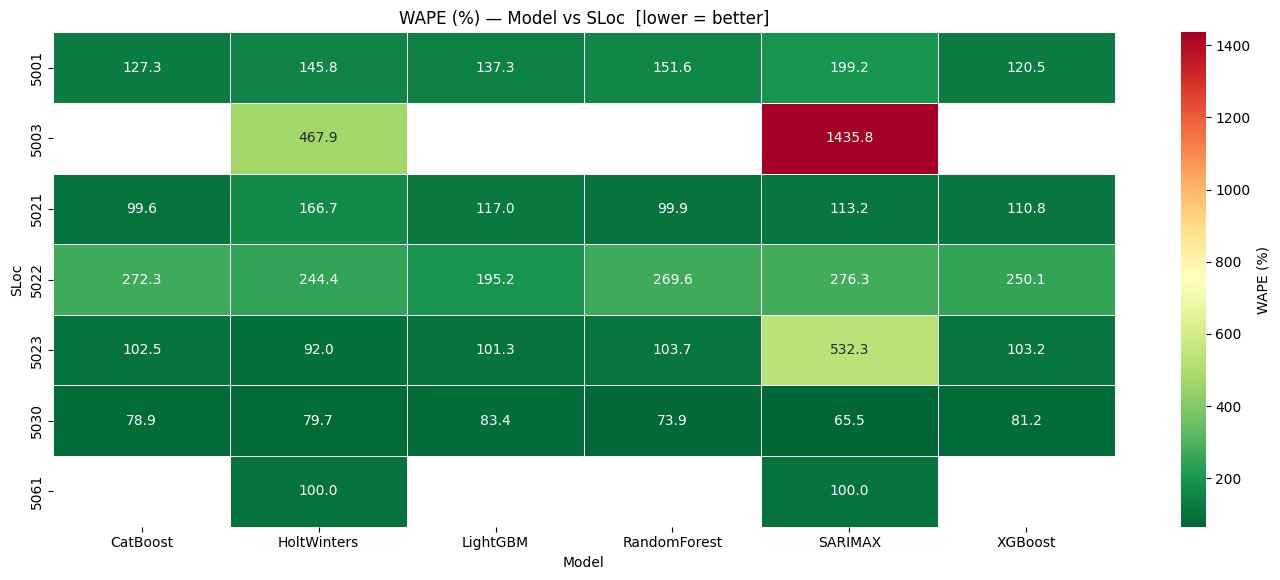

In [12]:
# Pivot: rows = SLoc, columns = Model, values = WAPE
# Include only SLocs with Tier 1 or 2 (enough data for comparison)
tier12_slocs = [s for s, t in all_tiers.items() if t in [1, 2]]

pivot_df = (
    summary_df[
        (summary_df['SLoc'].isin(tier12_slocs)) &
        (summary_df['Model'] != 'Ensemble')
    ]
    .pivot_table(index='SLoc', columns='Model', values='WAPE (%)')
)

plt.figure(figsize=(14, max(4, len(pivot_df) * 0.7 + 1)))
sns.heatmap(
    pivot_df,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'WAPE (%)'}
)
plt.title("WAPE (%) — Model vs SLoc  [lower = better]")
plt.tight_layout()
plt.show()

## 9. Forecast vs Actual — Tier 1 SLocs

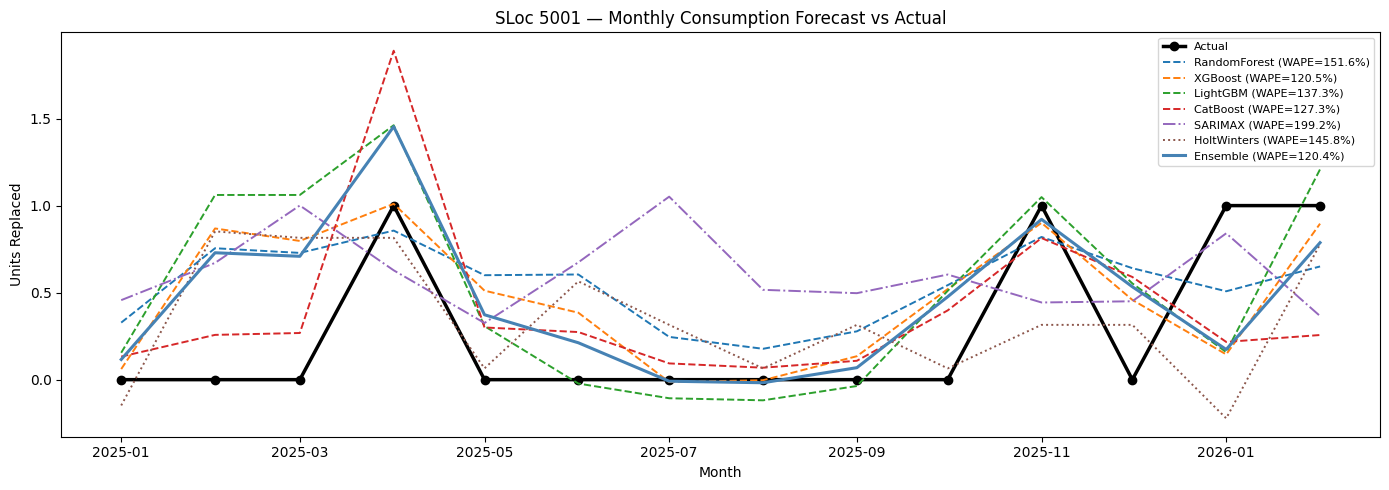

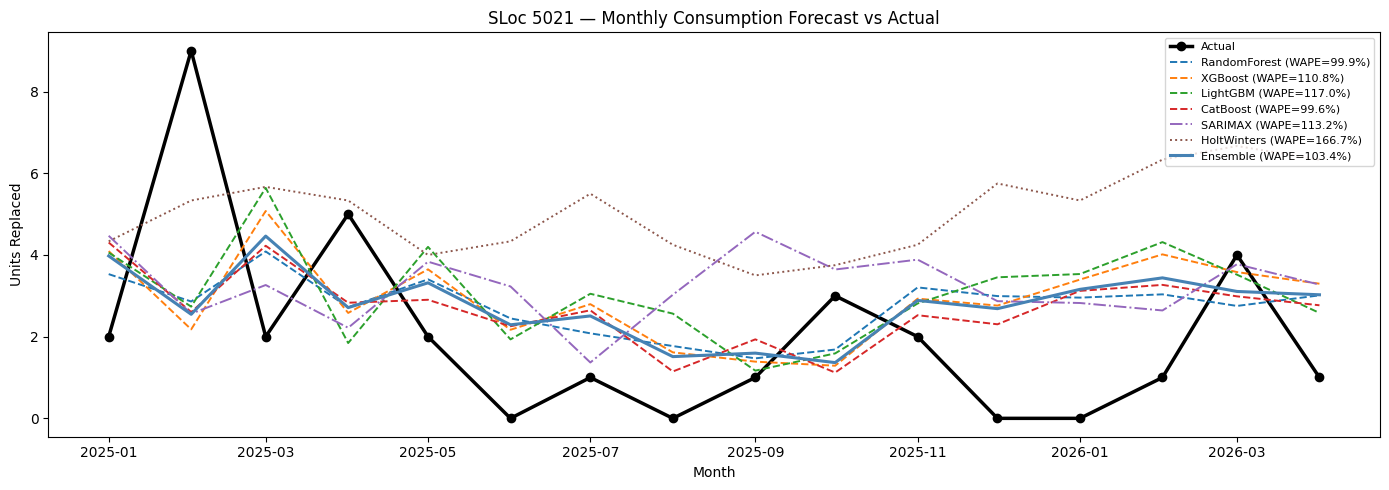

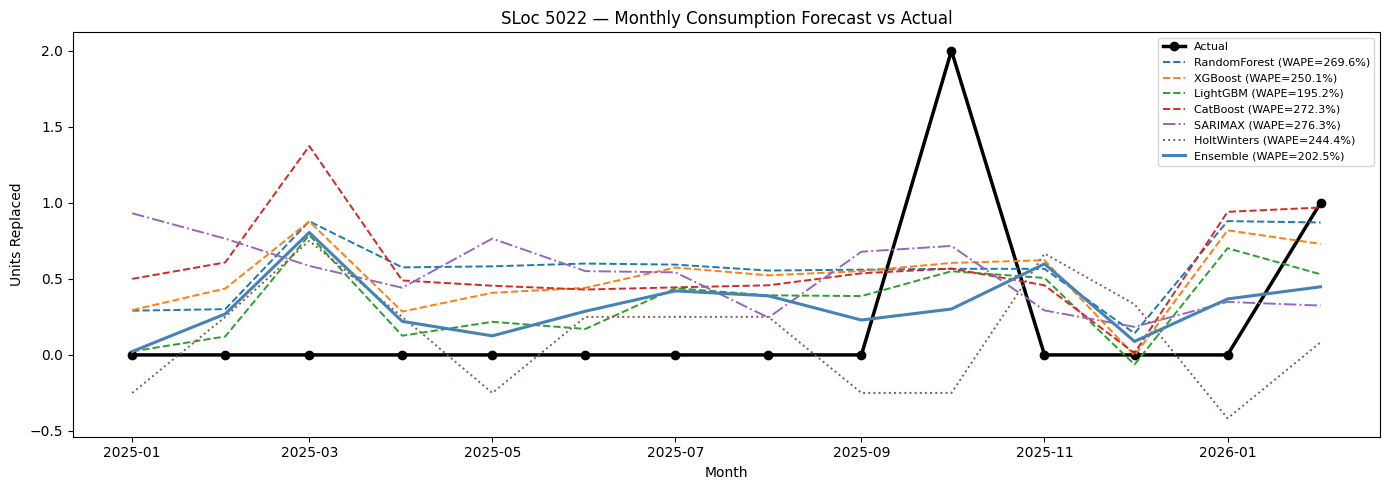

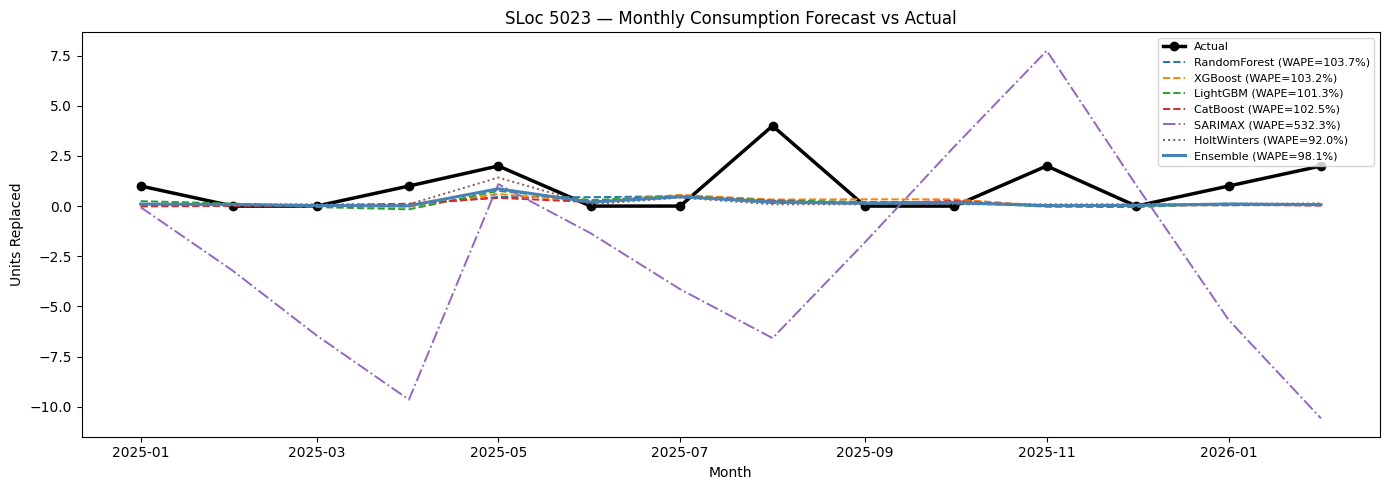

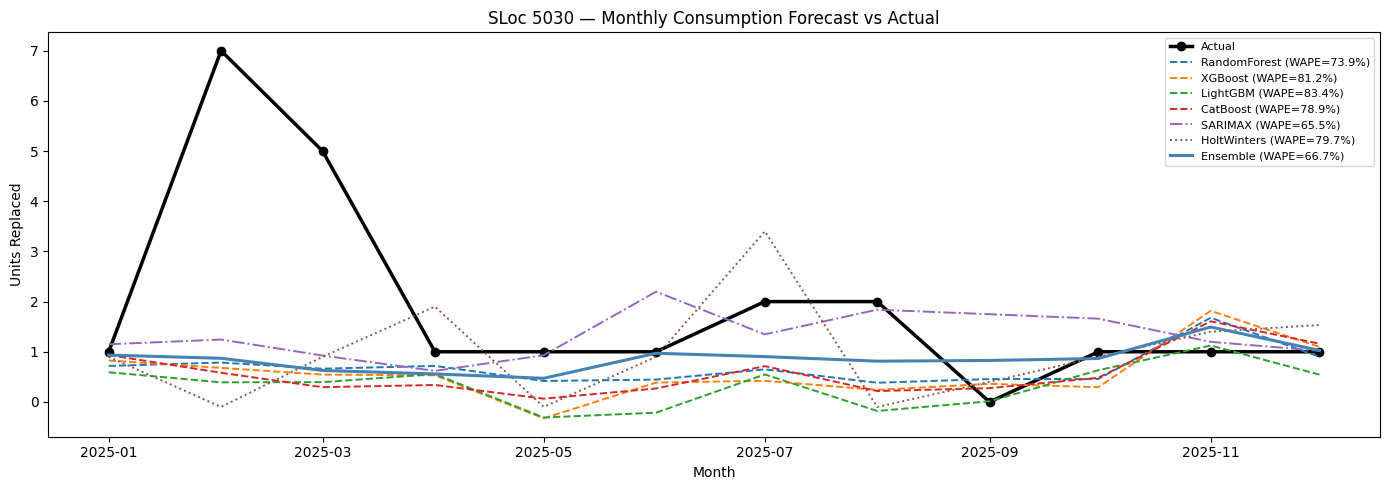

In [13]:
tier1_slocs = [s for s, t in all_tiers.items() if t == 1]

for sloc in tier1_slocs:
    test   = all_test_data[sloc]
    res    = all_results[sloc]
    dates  = test['Pstng Date']
    actual = test['Consumption'].values

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, actual, label='Actual', color='black', linewidth=2.5, marker='o')

    styles = {
        'RandomForest': ('--', 'tab:blue'),
        'XGBoost':      ('--', 'tab:orange'),
        'LightGBM':     ('--', 'tab:green'),
        'CatBoost':     ('--', 'tab:red'),
        'SARIMAX':      ('-.', 'tab:purple'),
        'HoltWinters':  (':',  'tab:brown'),
        'Ensemble':     ('-',  'steelblue'),
    }

    for model_name, (pred, mae, rmse, mape, wape) in res.items():
        ls, color = styles.get(model_name, ('--', 'grey'))
        lw = 2.2 if model_name == 'Ensemble' else 1.4
        ax.plot(dates, pred, label=f"{model_name} (WAPE={wape:.1f}%)",
                linestyle=ls, color=color, linewidth=lw)

    ax.set_title(f"SLoc {sloc} — Monthly Consumption Forecast vs Actual")
    ax.set_xlabel("Month")
    ax.set_ylabel("Units Replaced")
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

## 10. Forecast vs Actual — Tier 2 SLocs

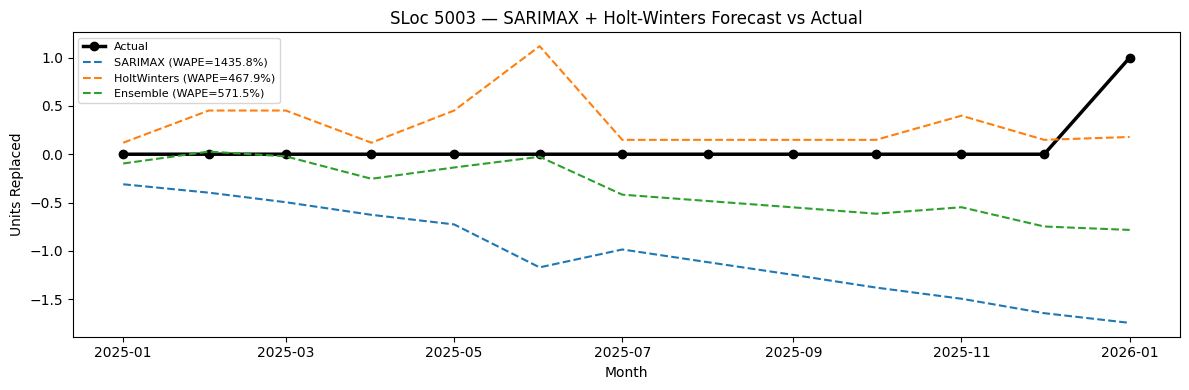

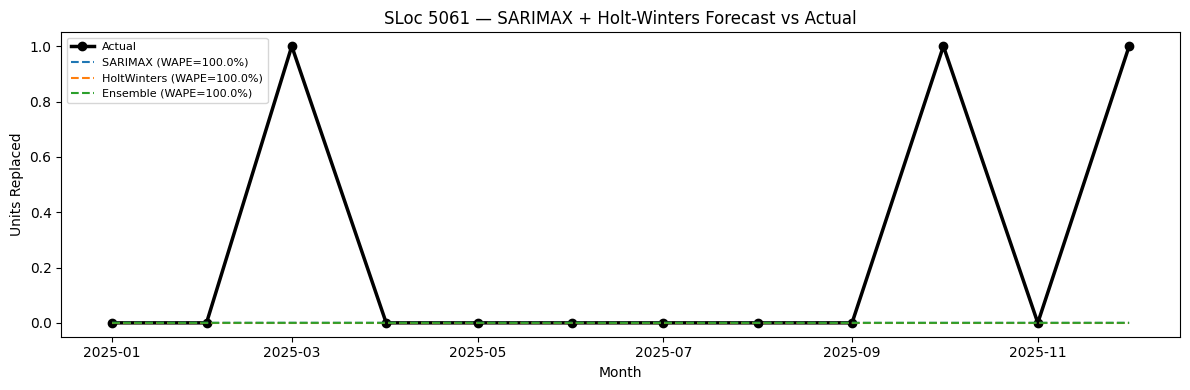

In [14]:
tier2_slocs = [s for s, t in all_tiers.items() if t == 2]

for sloc in tier2_slocs:
    test   = all_test_data[sloc]
    res    = all_results[sloc]
    dates  = test['Pstng Date']
    actual = test['Consumption'].values

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(dates, actual, label='Actual', color='black', linewidth=2.5, marker='o')

    for model_name, (pred, mae, rmse, mape, wape) in res.items():
        ax.plot(dates, pred, label=f"{model_name} (WAPE={wape:.1f}%)",
                linestyle='--', linewidth=1.5)

    ax.set_title(f"SLoc {sloc} — SARIMAX + Holt-Winters Forecast vs Actual")
    ax.set_xlabel("Month")
    ax.set_ylabel("Units Replaced")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 11. WAPE Bar Chart — Best Model per SLoc

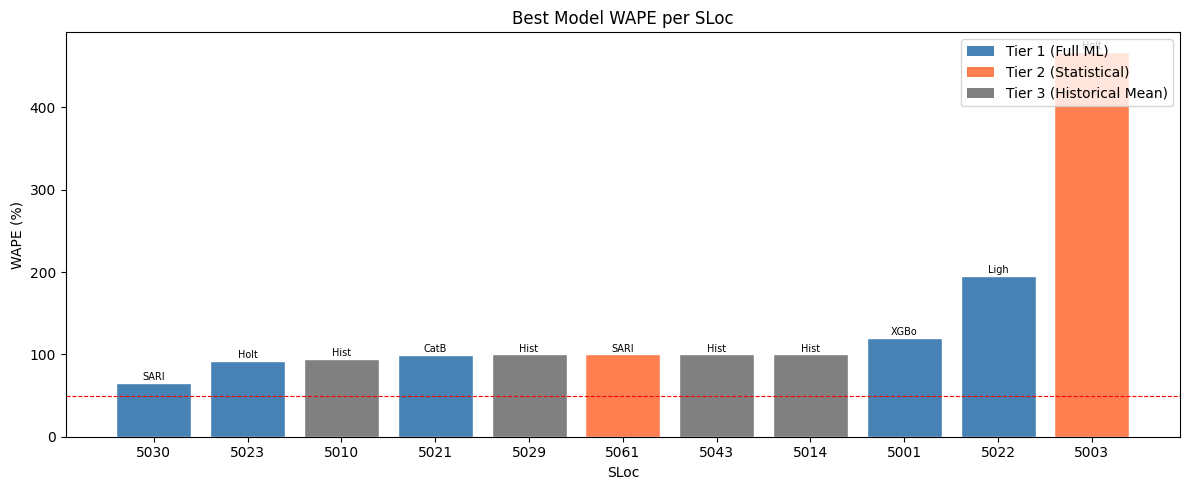

In [15]:
plot_df = best_per_sloc.dropna(subset=['WAPE (%)'])

colors = {'1': 'steelblue', '2': 'coral', '3': 'grey'}
bar_colors = [colors[str(row['Tier'])] for _, row in plot_df.iterrows()]

plt.figure(figsize=(12, 5))
bars = plt.bar(
    plot_df['SLoc'].astype(str),
    plot_df['WAPE (%)'],
    color=bar_colors,
    edgecolor='white'
)

for bar, (_, row) in zip(bars, plot_df.iterrows()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        row['Best Model'][:4],
        ha='center', va='bottom', fontsize=7
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Tier 1 (Full ML)'),
    Patch(facecolor='coral',     label='Tier 2 (Statistical)'),
    Patch(facecolor='grey',      label='Tier 3 (Historical Mean)')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50% WAPE')
plt.title("Best Model WAPE per SLoc")
plt.xlabel("SLoc")
plt.ylabel("WAPE (%)")
plt.tight_layout()
plt.show()

## 12. Export Results to Excel

In [16]:
output_path = "SLoc_Forecast_Results.xlsx"

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:

    # Sheet 1: Best model per SLoc
    best_per_sloc.to_excel(writer, sheet_name='Best_Model_Per_SLoc', index=False)

    # Sheet 2: All model results
    summary_df.to_excel(writer, sheet_name='All_Model_Results', index=False)

    # Sheet 3: Tier 1 SLoc predictions (month-by-month)
    pred_rows = []
    for sloc in tier1_slocs:
        test = all_test_data[sloc]
        res  = all_results[sloc]
        for i, date in enumerate(test['Pstng Date']):
            row = {
                'SLoc':   sloc,
                'Month':  date,
                'Actual': test['Consumption'].values[i]
            }
            for model_name, (pred, *_) in res.items():
                row[model_name] = round(float(pred[i]), 2)
            pred_rows.append(row)
    pd.DataFrame(pred_rows).to_excel(writer, sheet_name='Tier1_Monthly_Predictions', index=False)

    # Sheet 4: Tier assignments
    tier_df.to_excel(writer, sheet_name='Tier_Assignments', index=False)

print(f"Results saved to: {output_path}")

Results saved to: SLoc_Forecast_Results.xlsx
